In [1]:
# Top LORs writer

import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

path = '/home/kale-chen/Documents/PET/Spatial Resolution/Data/1723_pcut.bin'
num_cols = 3
data_type = np.int16

num_rows = os.path.getsize(path) // (num_cols * data_type().itemsize)
data = np.memmap(path, dtype = np.int16, mode = 'r', shape = (num_rows, num_cols))

In [2]:
# Event counts per LOR
eventcounts = np.zeros((3072, 3072), dtype = np.int32)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data[i:i+1000000]
    idls = np.asarray(chunk[:, 0], dtype = np.int32)
    idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    np.add.at(eventcounts, (idls, idrs), 1)
print(np.sum(eventcounts))

Event counts: 100%|██████████| 4/4 [00:00<00:00, 14.33it/s]

3633138


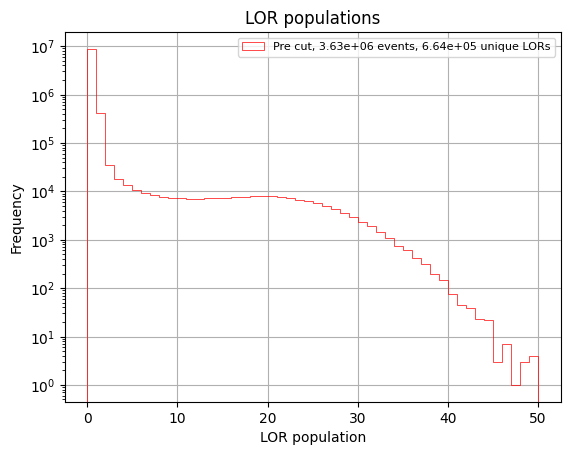

In [3]:
# LOR populations histogram
def format_number(number):
    return f"{number:.2e}"
plt.hist(eventcounts.flatten(), bins = np.max(eventcounts.flatten()), color = 'red', alpha = 1, label = f'Pre cut, {format_number(np.sum(eventcounts))} events, {format_number(len(np.where(eventcounts > 0)[0]))} unique LORs', histtype = 'step', linewidth = 0.5)
plt.yscale('log')
plt.xlabel('LOR population')
plt.ylabel('Frequency')
plt.title('LOR populations')
plt.grid()
legend = plt.legend(fontsize = 8)
plt.show()


In [4]:
lor_list = []
count = 0
for i in range(3072):
    for j in range(3072):
        if eventcounts[i, j] > 1:
            count += 1
            lor_list.append((i, j, eventcounts[i, j]))
lor_list = np.asarray(lor_list, dtype = np.int16)
sample_size = min(1000, len(lor_list))
sampled_lors = lor_list[np.random.choice(len(lor_list), sample_size, replace=False)]
print(sampled_lors.shape, count)
topl_filename = path.replace('.bin', '_toplors.bin')
with open(topl_filename, 'wb') as topl_fp:
    sampled_lors.tofile(topl_fp)


(1000, 3) 251699
